(solving-systems-of-odes-section)=

# Systems of ODEs

So far we have considered initial value problems involving a single differential equation. However, many real-world models involve several interacting quantities, each of which must be described by its own differential equation. Such models lead naturally to systems of ODEs. 

Recall that a single first-order ODE is expressed as a function of the single independent variable $t$ and a dependent function $y$

$$ y' = f(t, y). $$

A system of first-order ODEs is expressed as a set of multiple ODEs such that

$$ \begin{align*}
    y_1' &= f_1(t, y_1, y_2, \ldots, y_N), \\
    y_2' &= f_2(t, y_1, y_2, \ldots, y_N), \\
    & \vdots \\
    y_N' &= f_N(t, y_1, y_2, \ldots, y_N),
\end{align*} $$

where $y_1, y_2, \ldots, y_N$ are multiple dependent functions. An IVP involving a system of ODEs requires an initial value for each equation in the system, i.e., $y_1(t_0) = a_1$, $y_2(t_0) = a_2$ etc. where $a_1, a_2, \ldots, a_N$ are constants.  

To apply a numerical method to solve a system of ODEs, we can write it in vector form $\mathbf{y}' = \mathbf{f}(t, \mathbf{y})$ where

$$ \begin{align*}
    \mathbf{y} &= \begin{pmatrix} y_1 \\ \vdots \\ y_N \end{pmatrix}, &
    \mathbf{f}(t, \mathbf{y}) &= 
    \begin{pmatrix} 
        f_1(t, \mathbf{y}) \\
        \vdots \\
        f_N(t, \mathbf{y})
    \end{pmatrix}.
\end{align*} $$

Recall that the Euler method for solving an IVP for a single ODE is

$$ y_{n+1} = y_n + h \mathbf{f}(t_n, y_n). $$

Since vector addition and scalar multiplication are performed componentwise, the Euler method extends naturally to systems of ODEs

$$ \begin{align*}
    \mathbf{y}_{n+1} &= \mathbf{y}_n + h \mathbf{f}(t_n, \mathbf{y}_n).
\end{align*} $$

An important consequence of this vector formulation is that higher-order ODEs can be rewritten as systems of first-order ODEs. This allows numerical methods such as Euler's method and Runge-Kutta methods to be applied to a much wider class of problems.

`````{prf:example}
:label: sir-example

The <a href="https://en.wikipedia.org/wiki/Compartmental_models_in_epidemiology#The_SIR_model" target="_blank">SIR model</a> is a simple model that describes the spread of an infectious disease in a population. The model divides the population into three compartments: those who have not yet contracted the disease but are susceptible ($S$) those who are infected ($I$) and those who have recovered and gained immunity ($R$). The formulation of the model is

$$ \begin{align*}
    \frac{\mathrm{d}S}{\mathrm{d}t} &= -\dfrac{\beta}{N} IS, \\
    \frac{\mathrm{d}I}{\mathrm{d}t} & =\dfrac{\beta}{N} IS - \gamma I, \\
    \frac{\mathrm{d}R}{\mathrm{d}t} &= \gamma I,
\end{align*} $$

where $N = S + I + R$ is the total population, $\beta$ is the infection rate in the number of people per day who become infected, and $\gamma$ is the recovery rate at which a person who is infected recovers per day. 

A disease breaks out in a population where $\beta = 0.5$, $\gamma = 0.1$ and $S(0) = 99$, $I(0) = 1$ and $R(0) = 0$. compute the solution to the SIR model over the first 50 days using the Euler method with a step length of $h = 1$.

---

**Solution**

Let $y_1 = S$, $y_2 = I$ and $y_3 = R$ and writing the SIR model in vector form we have

$$ \begin{align*}
    \mathbf{y} &= \begin{pmatrix} y_1 \\ y_2 \\ y_3 \end{pmatrix}, &
    \mathbf{f}(t, \mathbf{y}) &= 
    \begin{pmatrix}
        -\dfrac{\beta}{N} y_1 y_2 \\
        \dfrac{\beta}{N} y_1 y_2 - \gamma y_2 \\
        \gamma y_2
    \end{pmatrix}.
\end{align*} $$

The initial conditions are $\mathbf{y}_0 = (99, 1, 0)$ and $N = 100$, $\beta = 0.5$, $\gamma = 0.1$ and $\beta/N = 0.005$. Calculating the first few steps of the Euler method with $h = 1$

$$ \begin{align*}
    \mathbf{y}_1 &= \mathbf{y}_0 + h \mathbf{f}(t_0, \mathbf{y}_0) \\
    &= 
    \begin{pmatrix} 99 \\ 1 \\ 0 \end{pmatrix} + 1 
    \begin{pmatrix} 
        -0.005 (99)(1) \\
         0.005 (99)(1) - 0.1(1) \\
         0.1(1) 
    \end{pmatrix}
    = 
    \begin{pmatrix} 98.505 \\ 1.395 \\ 0.1 \end{pmatrix}, \\
    t_1 &= t_0 + h = 0 + 1 = 1, \\ 
    \\
    \mathbf{y}_2 &= \mathbf{y}_1 + h \mathbf{f}(t_1, \mathbf{y}_1) \\
    &= 
    \begin{pmatrix} 98.505 \\ 1.395 \\ 0.1 \end{pmatrix} + 1 
    \begin{pmatrix} 
        -0.005 (98.505)(1.395) \\
        0.005 (98.505)(1.395) - 0.1(1.395) \\
        0.1(1.395)
    \end{pmatrix} = 
    \begin{pmatrix} 97.8179 \\  1.9426 \\  0.2395\end{pmatrix}, \\
    t_2 &= t_1 + h = 1 + 1 = 2, \\
    \\
    \mathbf{y}_3 &= \mathbf{y}_2 + h \mathbf{f}(t_2, \mathbf{y}_2) \\
    &= 
    \begin{pmatrix} 97.8179 \\ 1.9426 \\ 0.2395 \end{pmatrix} + 1 
    \begin{pmatrix} 
        -0.005 (97.8179)(1.9426) \\
         0.005 (97.8179)(1.9426) - 0.1(1.9426) \\ 
         0.1(1.9426)
    \end{pmatrix}
    = 
    \begin{pmatrix} 96.8678 \\  2.6984 \\  0.4338 \end{pmatrix}, \\
    t_3 &= t_2 + h = 2 + 1 = 3, \\
\end{align*} $$

The plot of the solutions to the SIR model using the Euler method for the first 50 days of the infection is shown in {numref}`sir-figure`

```{glue:figure} sir_plot
:name: sir-figure
:figwidth: 600
:alt: Euler method solutions for the SIR model

Euler method solutions for the SIR model with $S(0) = 99$, $I(0) = 1$, $R(0) = 0$, $\beta = 0.5$ and $\gamma = 0.1$.
```

The susceptible population decreases as individuals become infected, the infected population increases through transmission and decreases through recovery, and the recovered population increases as infected individuals recover.
``````

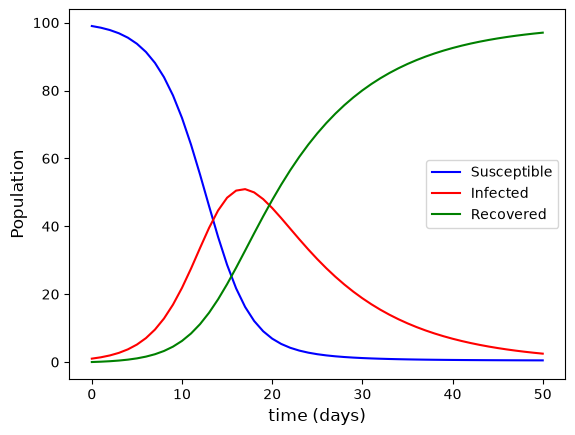

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define Euler method function
def euler(f, tspan, y0, h):
    
    # Determine the number of ODEs in the system
    N = len(y0)

    # Compute the number of steps required
    nsteps = round((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Loop through the steps and compute the Euler method solution
    for n in range(nsteps):
        y[n+1,:] = y[n,:] + h * f(t[n], y[n,:])
        t[n+1] = t[n] + h

    return t, y


# Define SIR model
def SIR(_, y):
    S, I, R = y
    N = S + I + R
    dS = -beta / N * I * S
    dI = beta / N * I * S - gamma * I
    dR = gamma * I
    return np.array([ dS, dI, dR ])


# Define IVP parameters
tspan = [0, 50]           # boundaries of the t domain
y0 = [99, 1, 0]           # initial values
beta, gamma = 0.5, 0.1    # Model parameters
h = 1                     # step length

# Solve the IVP using the Euler method
t, y = euler(SIR, tspan, y0, h)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y[:,0], "b-", label="Susceptible")
plt.plot(t, y[:,1], "r-", label="Infected")
plt.plot(t, y[:,2], "g-", label="Recovered")

plt.xlabel("time (days)", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.legend()
plt.show()

from myst_nb import glue
glue("sir_plot", fig, display=False)

## Coding the Euler method

You may have noticed that calculating the solution to an initial value problem using a numerical method using a pen, paper and calculator is a tedious exercise requiring lots of repeated calculations. Fortunately we have computers to do this work for us. Below is a function called `euler()` which solves a system of ODEs using the Euler method. 

`````{tab-set}
````{tab-item} Python
```python
def euler(f, tspan, y0, h):
    
    # Determine the number of ODEs in the system
    N = len(y0)

    # compute the number of steps required
    nsteps = round((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Loop through the steps and compute the Euler method solution
    for n in range(nsteps):
        y[n+1,:] = y[n,:] + h * f(t[n], y[n,:])
        t[n+1] = t[n] + h

    return t, y
```
This function assumes that the ODE function returns a NumPy array whos length equals the number of equations in the system. 
````

````{tab-item} MATLAB
```matlab
function [t, y] = euler(f, tspan, y0, h)

% Determine the number of ODEs in the system
N = length(y0);

% Compute the number of steps required
nsteps = floor((tspan(2) - tspan(1)) / h);

% Define solution arrays and assign initial values
t = zeros(nsteps + 1, 1);
y = zeros(nsteps + 1, N);
t(1) = tspan(1);
y(1,:) = y0;

% Loop through steps and compute the Euler method solution
for n = 1 : nsteps
    y(n+1,:) = y(n,:) + h * f(t(n), y(n,:))';
    t(n+1) = t(n) + h;
end

end
```
This function assumes that the ODE function returns an column vector whos length equals the number of equations in the system. 
````
`````

The inputs to the function are:

- `f` - the name of the ODE function to be solved (this needs to be defined elsewhere)
- `tspan` - an array containing the two values $t_0$ and $t_{\max}$
- `y0` - the initial values of the solution to the ODE
- `h` - the step length

The function computes the number of steps required to advance the solution from $t_0$ to $t_{\max}$ and then declares two arrays `t` and `y` in which the solution will be stored. The initial values $t_0$ and $y_0$ are copied into the first elements of `t` and `y` and then a for loop is used to compute the Euler method for each step.
 
The code below sets up and solves the SIR model example from {prf:ref}`sir-example` using the Euler method

`````{tab-set}
````{tab-item} Python
```python
# Define SIR model
def SIR(_, y):
    S, I, R = y
    N = S + I + R
    dS = -beta / N * I * S
    dI = beta / N * I * S - gamma * I
    dR = gamma * I
    return np.array([ dS, dI, dR ])


# Define IVP parameters
tspan = [0, 50]           # boundaries of the t domain
y0 = [99, 1, 0]           # initial values
beta, gamma = 0.5, 0.1    # Model parameters
h = 1                     # step length

# Solve the IVP using the Euler method
t, y = euler(SIR, tspan, y0, h)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y[:,0], "b-", label="Susceptible")
plt.plot(t, y[:,1], "r-", label="Infected")
plt.plot(t, y[:,2], "g-", label="Recovered")
plt.xlabel("time (days)", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.legend()
plt.show()

from myst_nb import glue
glue("sir_plot", fig, display=False)

print(y)
```
````

````{tab-item} MATLAB
```matlab
% Define SIR function
function y = SIR(~, y, beta, gamma)

S = y(1); 
I = y(2);
R = y(3);
N = S + I + R;
y = [ -beta / N * I * S ;
       beta / N * I * S - gamma * I;
       gamma * I ];

end

% Define IVP parameters
tspan = [0, 50];   % boundaries of the t domain
y0 = [99, 1, 0];   % initial values [S, I, R]
beta = 0.5;        % infection rate
gamma = 0.1;       % recovery rate
h = 1;             % step length

% Solve the IVP using the Euler method
[t, y] = euler(@(t, y)SIR(t, y, beta, gamma), tspan, y0, h);

% Plot solution
plot(t, y(:, 1), 'b-', LineWidth=2)
hold on
plot(t, y(:, 2), 'r-', LineWidth=2)
plot(t, y(:, 3), 'g-', LineWidth=2)
hold off
xlabel('$t$', Fontsize=14, Interpreter='latex')
ylabel('$y$', Fontsize=14, Interpreter='latex')
legend('Susceptible', 'Infected', 'Recovered', Location="east")
axis padded
```
````
`````